# [Thom Castro] — Individual Model Notebook
**Branch:** `student/thom_castro-model`

This notebook contains two architectures as required by AT3:
- **Model 1** (Phase 2): Individual architecture
- **Model 2** (Phase 3): Refined architecture based on group discussion

> **Prerequisites:** The shared `data_preparation.ipynb` must have been run at least once  
> and its outputs uploaded to the shared Google Drive folder before running this notebook.

## 0. Install dependencies

In [1]:
!pip install -q torch torchvision nltk Pillow matplotlib

## 1. Mount Google Drive & load processed data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# ── Shared Drive paths (must match data_preparation.ipynb) ───────────────────
DRIVE_FOLDER    = Path('/content/drive/MyDrive/AT3-DL-ImageCaptioning')
DRIVE_PROCESSED = DRIVE_FOLDER / 'processed'
DRIVE_IMAGES    = DRIVE_PROCESSED / 'images_224'
DRIVE_CHECKPTS  = DRIVE_FOLDER / 'checkpoints'

STUDENT_NAME = 'thom_castro'  # <-- CHANGE THIS
MY_CHECKPTS  = DRIVE_CHECKPTS / STUDENT_NAME
MY_CHECKPTS.mkdir(parents=True, exist_ok=True)

# Verify Drive artefacts exist
for p in [DRIVE_PROCESSED / 'vocab.pkl',
          DRIVE_PROCESSED / 'splits.json',
          DRIVE_PROCESSED / 'captions_clean.json']:
    status = 'OK' if p.exists() else 'MISSING — run data_preparation.ipynb first'
    print(f'[{status}] {p.name}')

n_imgs = len(list(DRIVE_IMAGES.glob('*.jpg')))
print(f'[OK] images_224/ — {n_imgs:,} images')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[OK] vocab.pkl
[OK] splits.json
[OK] captions_clean.json
[OK] images_224/ — 7,750 images


In [3]:
import pickle, json, random
import numpy as np

with open(DRIVE_PROCESSED / 'vocab.pkl', 'rb') as f:
    vocab = pickle.load(f)

word2idx   = vocab['word2idx']
idx2word   = vocab['idx2word']
PAD_IDX    = vocab['PAD_IDX']
SOS_IDX    = vocab['SOS_IDX']
EOS_IDX    = vocab['EOS_IDX']
UNK_IDX    = vocab['UNK_IDX']
VOCAB_SIZE = len(word2idx)

with open(DRIVE_PROCESSED / 'splits.json') as f:
    splits = json.load(f)

with open(DRIVE_PROCESSED / 'captions_clean.json') as f:
    clean_data = json.load(f)

captions_clean = clean_data['captions']
id_to_filename = clean_data['id_to_filename']

print(f'Vocab size   : {VOCAB_SIZE:,}')
print(f'Train images : {len(splits["train"]):,}  Val: {len(splits["val"]):,}  Test: {len(splits["test"]):,}')

Vocab size   : 3,965
Train images : 6,181  Val: 772  Test: 774


- word2idx: Converts words to numbers. Done
- idx2word: Converts numbers to words. Done
- PAD_IDX: Padding token (0)- Used to fill short captions to match the longest caption. Done
- SOS_IDX: Start of sentence token. Added at the begginning of every caption.
- EOS_IDX: End of sentence token. Model needs to learn to stop at this point. Done
- UNK_IDX: Unknown token - words not in vocabulary. Done
- VCAB_SIZE: Total number of Known words. Total 3965. Done


## 2. Imports & device setup

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchvision.models import googlenet, GoogLeNet_Weights
from nltk.translate.bleu_score import corpus_bleu
import nltk
nltk.download('punkt')

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

import os 
import numpy as np
import random
import matplotlib.pyplot as plt
import numpy as np
import random

from tqdm import tqdm # Downloading tqdm to show progress

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## 3. Dataset & DataLoader

In [5]:
class VizWizDataset(Dataset):
    """Loads 224x224 images from Drive and tokenised captions from memory."""

    def __init__(self, image_ids, captions, id_to_filename, img_dir, word2idx, transform=None):
        self.samples = []
        for img_id in image_ids:
            img_id_str = str(img_id)
            fname = id_to_filename.get(img_id_str)
            if fname is None:
                continue
            for tokens in captions.get(img_id_str, []):
                indices = ([SOS_IDX]
                           + [word2idx.get(t, UNK_IDX) for t in tokens]
                           + [EOS_IDX])
                self.samples.append((img_dir / fname, indices))

        self.transform = transform or T.Compose([
            T.Resize((224,224)), # I had to add this
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, caption_indices = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        return self.transform(img), torch.tensor(caption_indices, dtype=torch.long)


def collate_fn(batch):
    images, captions = zip(*batch)
    images = torch.stack(images)
    lengths = [len(c) for c in captions]
    padded = torch.zeros(len(captions), max(lengths), dtype=torch.long)
    for i, cap in enumerate(captions):
        padded[i, :len(cap)] = cap
    return images, padded, torch.tensor(lengths)

In [6]:
# Verivying is Pad is 0.
print(PAD_IDX)

0


In [7]:
BATCH_SIZE = 64 # it was 32 before. Trying to make training faster

train_dataset = VizWizDataset(splits['train'], captions_clean, id_to_filename, DRIVE_IMAGES, word2idx)
val_dataset   = VizWizDataset(splits['val'],   captions_clean, id_to_filename, DRIVE_IMAGES, word2idx)
test_dataset  = VizWizDataset(splits['test'],  captions_clean, id_to_filename, DRIVE_IMAGES, word2idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn, num_workers=2) # It was 0. Changed to 2 to try to make things faster on colab
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2) # It was 0. Changed to 2 to try to make things faster on colab
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2) # It was 0. Changed to 2 to try to make things faster on colab

print(f'Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

Train batches: 469  Val: 59  Test: 59


In [8]:
print(DRIVE_IMAGES)
print(len(list(DRIVE_IMAGES.glob('*.jpg'))))

/content/drive/MyDrive/AT3-DL-ImageCaptioning/processed/images_224
7750


---
# Model 1 — Phase 2 (Individual Architecture)
The MobileNetV2 was selected for model 1 because of its computational efficiency, making it one of the most suitable for training within Colab’s environment, while still providing strong feature extraction capabilities through its pretrained ImageNet weights.  MobileNetV2 was designed to be both lightweight and efficient. Due to the relatively small size of the VizWiz dataset from today standards, training a CNN from 0 would not produce good results fast and since the MobileNetV2 was already pretrained on ImageNet, it is already trained to recognize visual patterns from vast range of images.  Basically, I am using MobileNetV2 to transfer its image learning to my model. Since MobileNetV3 was already being used by one of my teammates in another model, I am focusing on MobileNetV2 + GRU. MobileNetV2 is the standard baseline in image captioning literature; it is older, results are easier to compare and require less computational power. 

Shape flow of the imagem on the encode model.
1) Input   : 64 Images (64, 3, 224, 224). So I have 64 RGB images, each 224x224 pixels.

2) self.cnn: MobileNetV2 extracts features (64,1280, 7, 7). Processes each image and outputs 1280 channels with 7 x 7 spatial grid. 

3) self.pool: AdaptiveAvgPool2d compresses to (64, 1280, 1, 1). Each 7 x 7 feature map is summarized into a single value.

4) flatten (64,1280). Now each image  is represented by a vector of 1280 numbers.

5) self.fc : compress to embed_size (64,256). The fc maps each 1280 dimensional vector into a smaller 256-dimensional vector. Each image will be compressed to a vector of 256 features per image.


Therefore the code will have two big parts, the EncodeCNN that looks at the image and turns it into numbers and the DecoderRNN that uses those numbers to generate a caption. 

Image > EncoderCNN > Image Features > DecoderRNN > Caption Words.

A car image becomes 256 numbers and the output might be " The car is parked"

Below, I start by creating my own neural network class called EncoderCNN and its job is to understand the images. I am using the resnet model since this model was already trained to understand many image patterns. For image captioning, I am only interested on the feature extraction done by the model, not on its classification power, therefore I am removing the classifier head and keep only the feature extractor. The MobileNetV2 backbone outputs 1280 features per image, which are then compressed to 256 number by the fully connected layer.

Inspecting MobileNetV2 Structure before building my encoder on top of it

In [9]:
structure_model = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
print(structure_model)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

The network has two parts:
- Features: 19 layers of convolutions. This is what I want, I dont need the classifier. 19 layers ending with 1280 feature channels.
- Classifier: Dropout 0.2 + Linear(1280 to 1000). The classifier was originally trained to predict 1000 ImageNet categories. Since it is used for classification, I will not use this part. I will only need the umage features to feed into the GRU.I will only keep the features and add my own fc layer.
- Conv2d(320 > 1280): This is was the encoder outputs 1280 features before our fc compresses it to 256.

The last convolutional layer outputs 1280 features, so when building my encoder, it will initially get a vector of 1280 numbers per image

In [10]:
structure_list = list(structure_model.children())
for i, child in enumerate(structure_list):
    print(i, child.__class__.__name__)

0 Sequential
1 Sequential


- 0 Sequential: Features. Keep.
- 1 Sequential: Classifier. Remove.
Testing Removing Classifier. Testing the Removal of the classification head before using the pretrained model as feature extractor.

In [11]:
structure_list = list(structure_model.children())[:-1]
for i, child in enumerate(structure_list):
    print(i, child.__class__.__name__)

0 Sequential


In [12]:
print(structure_list[0])

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU6(inplace=True)
  )
  (1): InvertedResidual(
    (conv): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (2): InvertedResidual(
    (conv): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (

Starting from 0. 19 Convolutional layers.

In [13]:
print(structure_list[0])

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU6(inplace=True)
  )
  (1): InvertedResidual(
    (conv): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (2): InvertedResidual(
    (conv): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (

In [14]:
print(list(structure_model.children())[0])

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU6(inplace=True)
  )
  (1): InvertedResidual(
    (conv): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (2): InvertedResidual(
    (conv): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (

In [15]:
print(list(structure_model.children())[1])

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


Before building the encode, sending an image example to the features to understand the output shape. Should be 1 image, 1280 features channels and grid 7 x 7.

In [16]:
test = torch.randn(1, 3, 224, 224)
out = structure_model.features(test)
print(out.shape)

torch.Size([1, 1280, 7, 7])


1 image, 1280 features, 7 x 7 grid due to stride that happens 5 times on MobileNet.

# Setting Up Encoder and Decoder

The encoder understands the image while the decoder writes the sentence.
Input image might be: "a car is parked". The encoder will turn the image into numbers. The decoder will use these numbers to generate "there is a car parked ".
- MobileNet backbone: I will keep it fronzen since it already know how chek important features from the iage.
- Encoder fc: fc  will be unfrozen, being able to learn to summarise for the decoder.
- Decoder GRU + fc - They will learn to generate captions.

Since MobileNet already learned to understand images from ImageNet, we only need to teach the model how to coonect image features to words.

Quick review:
- input(64, 3, 224, 224) 
- CNN     (64, 1280, 7, 7) MobileNet feature extraction
- pool    (64, 1280, 1, 1) Compress spatial grid
- flatten (64, 1280) Remove the spatial dimentions after pooling
- dropout (64, 1280) Regularization to avoid overfitting
- fc      (64,256) compress to embed size

In [17]:
# Setting up Encoder and Decoder.
# We start with the image features, give it to the GRU, GRU predicts the first word, save in memory, convert the word into  an embedding, give back to GRU, GRU predicts next word, repeat until <EOS> or max_len 30, returne the generated word indexes or ids.

# Encoder -> MobileMet V2  + Dropout
class EncoderCNN(nn.Module): # This creates a Pythorch neural network class, as we have seen in lecture i believe 6 and 7, but the professor uses another name.  Encoder to understand image patterns. Creatign encoder class. It will inherit from nn.Module, pyttorch base class for all neural networks.
    """Feature extractor using a pre-trained CNN."""
    # nn.Module is the base class for nn in pytorch, every custom model inherits from it.
    # The job of this encoder is to take an image and convert it into a vector of numbers, for example image ------>[0.33, 0.13, 0.56...]. 

    def __init__(self, embed_size): # embeded size is how many numbers represents each image. In this case, 256. Each image becomes 256 numbers.
        super().__init__() # Initialises the parent nn M.Module class
        
        mobilenet = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT) # Downloading mobilenet with the weights already trained on images. We will keep only the feature extractor. We dont care for the classifier. I want the MobileNet to describe the image in a way the decoder understands.
        self.cnn = mobilenet.features # MobileNetV2 has two main parts, feature extractor and classfier. MobileNetV2 outputs features maps, for each image batch,  the shape will be (batch_size, 1280, 7, 7). Batch size 64 is (64, 1280, 7, 7). ¨4 images, 1280 feature channels per image, each feature with size 7 x 7.
        self.pool= nn.AdaptiveAvgPool2d((1,1)) # Adding pool, different than v3. (1280, 1, 1).  It compresses each 7 x7 feature map into  one number. Pooling summarizes each featuee map into a value. stirde=(2,2) keeps changings images size by half from 224, 112, 56, 28, 14, until 7. There are 5 stride=(2,2) on MobileNet structure, reducing image to 7x7.
        self.dropout = nn.Dropout(0.5) # Dropout will help reduce overfitting by randomly turning off values during training, forcing the model to not depend too much on only a few features.
        self.fc = nn.Linear(1280, embed_size) # mobilenet gives 1280 numbers per image, but I need to compress it to 256 since the decoder expects 256. The images becomes smaller and easier for the decoder to use. This layer changes 1280 to 256, becoming a summary that we pass to the decoder.

    def forward(self, images): # This will run when I pass images into the encode. Images is a batch of 64 images, shape (64,3,224,224)
        features = self.cnn(images) # (64, 1280, 7, 7) This sends images through mobilenet. 
        features = self.pool(features) # After pooling, shape is (64, 1280, 1, 1). Pooling keeps the important feature information but removes the spatial grid by providing a new summary 1 x 1.
        features = torch.flatten(features, 1) # shape changes to (64, 1280). Since dimension 0 is Batch Size, it flattens from dimension 1, keeping dimension 1. Now, each image is represented by 1280 numbers.
        features = self.dropout(features) # (64,1280) Applying dropout. Each image is represented by 1280 numbers, dropout will randomly turn off 50% of these numbers during training.
        features = self.fc(features) # Shapes is (64, 1280) changes to (64,256). Each image is now represented by 256 numbers.
        return features # Encoder returns each image into a 256 number summary.
    
    # Logic  (64, 3, 224, 224) > (64, 1280, 7, 7) > (64, 1280, 1, 1) > (64,1280) > (64,256). This completes the encoder.
    




Now, setting up the decoder:

Forward:
- captions[:, :-1] remove EOS from input
- embed + dropout (64, seq_len - 1, 256)
- features.unsqueeze (64, 1, 256)
- torch.cat (64, seq_len, 256)
- GRU (64, seq_len, 512)
- outputs[:,1:,:] remove image step
- fc (64, seq_len - 1, 3965)

Generate:
- unsqueeze (1, 1, 256)
- hidden = none, no memory.
- loop up 30x:
--GRU predict next word
--argmax picks highest score
--EOS check stop if embed of sentence
--embed feed word back in
--return result return list of words indices

Idea during my training:
Captions as token Ids:
- Full caption:      [SOS, 'a', 'car', 'is', 'parked', EOS]
- supposed indiece:  [10, 20, 23, 30, 100, 13]

Removing EOS: captions[:, :-1]:
- Input   [10, 20, 23, 30, 100, 13]
- Becomes [10, 20, 23, 30, 100]
-         [SOS,'a','car','is','parked']

Embedding words:
- SOS      [0.3, 0.4, 0.8, 0.45...] 256 numbers
- 'a'      [0.3, 0.4, 0.8, 0.45...] 256 numbers
- 'car'    [0.3, 0.4, 0.8, 0.45...] 256 numbers
- 'is'     [0.3, 0.4, 0.8, 0.45...] 256 numbers
- 'parked' [0.3, 0.4, 0.8, 0.45...] 256 numbers
During embedding, they each becomes a vector of 256 numbers.

Adding image features at the front
- [IMAGE, SOS, 'a', 'car' , 'is', 'parked'] IMAGE is the image features descrbing the car photo.

GRU reads sequence:
-1) reads IMAGE > Updates memory
-2) reads SOS > Updates memory and predicts 'a'
-3) reads 'a' > Updates memory and predicts 'car'
-4) reads 'car'...............
-5) read 'parked' > Updates memory and predicts EOS

- Remove image step output:
[SOS output, 'a' output, 'car' output, 'is' output, 'parked' output]

FC converts to word scores:
- 'SOS' output > scores for 3965 words > highest score = 'a'
- 'a' output > scores for 3965 words > highest score = 'car'
- 'car' output > scores for 3965 words > highest score = 'is'
- 'is' output > scores for 3965 words > highest score = 'parked'
- 'parked' output > scores for 3965 words > highest score = 'EOS'

generate()
- Now the model has no real caption and generate words
- input= IMAGE     > GRU > FC > Predicts 'a'      save 'a'
- input= 'a'       > GRU > FC > Predicts 'car'    save 'car'
- ...
- input = 'parked' > GRU > FC > Predicts 'EOS'    stop here
- result = ['a', 'car','is','parked']

So basically what is going on is that I pass an imafe through the ENCODER, for example, the photo of a car > EncoderCNN > [0.25, 0.37,0,45...256 numbers]. I pass the 256 numbers  vector to DecoderRNN.generate() and it generates words one by one based on what the encoder saw in the image:

- 256 numbers > GRU > 'a'
- 'a'         > GRU > 'car
- 'car'       > GRU > 'is'
- 'is'        > GRU > 'parked'
- 'parked'    > GRU > 'EOS' > STOP
- Result: 'A car is parked'







In [18]:
# Decoder -> GRU + Dropout.
# The encoder finishes with each image being represented by 256 numbers. Now the decoder takes these 256 number and generate words. Receives image features and generate words.
# 256 image numbers > "a car is parked". EncoderCNN understands the image, DecoderRNN writes the sentence.
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers = 1): # embed_size is ths size of each image vector. hidden_size in the GRU memory.
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size) # This creates an embedding layer, voncerting word number into useful vectors. The letter 'car' becomes a number, for example, 13 and after embedding it becomes as vector like [0.14, 2.5, 2.67, ...] made of 256 numbers. Each Word ID becomes a vector. as embed size = 256, each word becomes 256 numbers word vector. 'car'> 13> a vector of 256 numbers.
        self.dropout = nn.Dropout(0.5) # Dropout to avoid overfitting
        self.gru = nn.GRU(embed_size, hidden_size, num_layers, batch_first=True) # The GRU receives 256 numbers, outputs 512 numbers, later is scores for every word in vocabulary. The GRU internal memory is represented by 512 number per word. This is the mais caption generator part of the decoder. At each word step, the GRU creates a vector. There are 512 number inside this vector. Therefore each word is represented by 5212 numbers. The GRU reads a sequence step by step. It looks at one step, update its memory, and moves to the next step. batch_first = True expects (batch_size, sequence_lenght, embed_size), (64 images, 20 time steps and 256 numbers on a vector). The GRU reads the image and words in order, remember the context and helps predicting the next word.
        self.fc = nn.Linear(hidden_size, vocab_size) # Take the 512 GRU numbers and convert them into word scores. The GRU outputs a vector of numbers The model needs to predict a word. It receives 512 number and scores for every word in the vocabulary. The word with highest score is returned.
        # Because the vocabulary has many words, the decoder needs to give a score to every possible word.

    
    def forward(self, features, captions): # It is used during training. It receives features from the encoder (64,256) and captions, real captions  from the dataset converted into word IDs. Forward teaches the decoder how to write caption by using the caption from the dataset
        embeddings = self.embed(captions[:, :-1]) # Removes the last token from captions. During training, the model has to learn to predict the correct next word. The correct target is 'a car is parked', the input is 'a car is' so the model can learn the next word.
        embeddings = self.dropout(embeddings) # Turn id numbers into vectors. Each word became a number, and is now becoming a 256 number vector. (64, 19(result from 20-1), 256)
        features = features.unsqueeze(1) # features shape is (64, 256) to (64, 1, 256). GRU expects 3 dimension and features only had 2. We do unsqueeze(1) to add a new dimension in position 1.
        inputs = torch.cat((features, embeddings), dim=1) # Joining features:(64, 1, 26) and embeddings:(64, 19, 256) on dimension 1. (64, 20, 256) 
        outputs, _ = self.gru(inputs) # at this point  shape is (64, 20, 256), 64 examples, 20 sequence steps, 256 number per step. The GRU reads the sequence step by step and return outputs. output shape will be 64,20, 512 with hidden step. input 256 per step to GRU and GRU outputs 512 numbers per step.
        outputs = outputs[:, 1:, :] # Removing the first time step, which is the image we placed before GRU. GRU output (64, 20, 512). We remove the image step because it was used for context, not as a word prediction. Now (64, 19, 512). Convert each 512 GRU number into scores for every word in the vocabulary. One word position  becomes 512 GRU numbers, then FC changes these 512 numbers into 4000 word scores, the biggest score represents the word at thar word position.
        
        return self.fc(outputs)
    # (64,20) > remove last token for time step. (64,19) > Embedding (64, 19, 256): join features(64, 1, 256) with caption embedding(64, 19, 256). 1 + 19 = 20. 19 is the time step, when we add an image we add an tie step. We add the image to the sequence so the GRU sees the image before reading and generating words.
    # An original caption has 20 token positions, we remove the last token, leavign 19 word token postion inputs. We add the image feature as one extra GRU input step, so the GRU receives 20 steps total, 1 image step + 19 word steps, but we add only for context and remove it after GRU.

    def generate(self, features, max_len=30): # While forward is used for training because I have the real captions, generate is used after training to make the model generate new captions. We will use it during testing.It will create captions without real captions. Using trained model create captione.Generating captions using image features with  max  lenght of 30 words
        result = [] # Empty list to collect generated index words predicted by the model
        inputs = features.unsqueeze(1) # Image features and input. (1,256) meaning 1 image and 256 features. GRU expects 3 dimension so we change to (1, 1, 256), batch size, sequence_lenght, embed size. Captions are genereted 1 by 1 because of single_image.
        hidden = None # Guarantees start of GRU with no memory

        for _ in range(max_len): # Trying to generate 30 words, one word at a time. Starting the Generation Looping max 30 times. Each loop predicts 1 word. It stops early if the model predicts <EOS>.
            output, hidden = self.gru(inputs , hidden) # pass current input(image features) on GRU and GRU updates memory. Hidden memory now contains information about the image after first loop. The GRU outputs gets output and updates memory.
            # 1) input = image features, gru updates memory, model predicts 'a'. 2) input = 'a', gru updates memory, model predicts 'car'...
            predicted = self.fc(output).argmax(dim=2) # output is a vector of numbers, 512, self.fc converts the 512 numbers into scores for all words in the vocabulary and picks the word with highest score. dim 0 is batch_size, dim 1 is sequence step, dim 2 is vocabulary word score, we want the max from last one.
            word_idx = predicted.item() # Tensor to a python number(word id).

            if word_idx == EOS_IDX: # Stop generating when the model predicts end of end of the sentence.
                break
            result.append(word_idx) # Save the current predicted word id or index. I am doinf idx2word[word_idx] > idx2word[13] > 'car'
            inputs = self.embed(predicted) #  GRU cant use a number directly as input, it expects a vector, so we embed it. Embedding the predicted word to use as next input. 
        
        return result

In [19]:
# Setting up model for training
# Below, I am creating the decoder and the encoder, freezing MobileNetV2 weights, taking a batch from train loader, creating optimizer, sendi images through encode, send encoder features  and captions to decode.

EMBED_SIZE  = 256  # Each image feature and word embedding contains 256 numbers. It controls the size of the image and word vectors.
HIDDEN_SIZE = 512  # It controls the size of GRUs memory.
NUM_LAYERS  = 1 # Since model is taking too long to train, I will only use one layer, also, it is less likely to overfit.
EPOCHS      = 15 # Training for 15 epocchs
LR          = 3e-4 # Control the size of updates during training. this is equal to 0.0003. It is a commom choice for Adam.

# Creating encoder and decoder
encoder_mobilenet = EncoderCNN(EMBED_SIZE).to(DEVICE) # Creating encoder. The encode will output image features of size 256. Sending model to device.
decoder_gru = DecoderRNN(EMBED_SIZE, HIDDEN_SIZE, VOCAB_SIZE, NUM_LAYERS).to(DEVICE) # Creating decoder. It receives 256 word embeddings, it outputs 512 number as memory, final output give scores for vocab_size words, only 1 layer for faster training. Sending model to device

# Freezing weights
for param in encoder_mobilenet.cnn.parameters(): # Updates during training are frozen, just updating the encoder fc layer and the decoder GRU.
    param.requires_grad = False

images, captions, lengths = next(iter(train_loader)) # Gets a batch from training_loader. Verifying shapes.
images = images.to(DEVICE) # Moving images and captions to device
captions = captions.to(DEVICE)

# Creating optimizer afetr freezing
optimizer1 = optim.Adam(list(encoder_mobilenet.parameters()) + list(decoder_gru.parameters()), lr=LR) # Update model weights during training. The loss tells us how wrong the model is, and Adam optimizer changes weights to decrease the loss. MobileNet cnn is frozen, only the fc is unfrozen..

features = encoder_mobilenet(images) # Sending bath of images into the encoder
print(f'Encoder output shape: {features.shape}') # Images start with shape (64, 3, 224, 224) but the encode does MobileNetV2>Pooling>Flatten > Dropout > Linear Layer, and becomes (64,256). Verifyin if shape is (64,256)
outputs = decoder_gru(features, captions) # features (64,256), captions (64, caption_lenght). Converts caption indexes into embeddings, add image feature as the first GRu step, run everything to GRU, remove image output step, convert gru outputs into word scores. So the output shoul look like(64, 19, 3965)
print(f'Decoder output shape: {outputs.shape}') # Verifying if it is (64, seq_len, vocab_size = 3965). Seq len will always change to to shuffle=True, but vocab size and batch size needs to be the same.

Encoder output shape: torch.Size([64, 256])
Decoder output shape: torch.Size([64, 25, 3965])


26 -1 = 25

In [20]:
captions.shape

torch.Size([64, 26])

In [21]:
print('Encoder parameters:')
for name, param in encoder_mobilenet.named_parameters():
    status = 'trainable' if param.requires_grad else 'frozen'
    print(f'  {name}: {status}')

Encoder parameters:
  cnn.0.0.weight: frozen
  cnn.0.1.weight: frozen
  cnn.0.1.bias: frozen
  cnn.1.conv.0.0.weight: frozen
  cnn.1.conv.0.1.weight: frozen
  cnn.1.conv.0.1.bias: frozen
  cnn.1.conv.1.weight: frozen
  cnn.1.conv.2.weight: frozen
  cnn.1.conv.2.bias: frozen
  cnn.2.conv.0.0.weight: frozen
  cnn.2.conv.0.1.weight: frozen
  cnn.2.conv.0.1.bias: frozen
  cnn.2.conv.1.0.weight: frozen
  cnn.2.conv.1.1.weight: frozen
  cnn.2.conv.1.1.bias: frozen
  cnn.2.conv.2.weight: frozen
  cnn.2.conv.3.weight: frozen
  cnn.2.conv.3.bias: frozen
  cnn.3.conv.0.0.weight: frozen
  cnn.3.conv.0.1.weight: frozen
  cnn.3.conv.0.1.bias: frozen
  cnn.3.conv.1.0.weight: frozen
  cnn.3.conv.1.1.weight: frozen
  cnn.3.conv.1.1.bias: frozen
  cnn.3.conv.2.weight: frozen
  cnn.3.conv.3.weight: frozen
  cnn.3.conv.3.bias: frozen
  cnn.4.conv.0.0.weight: frozen
  cnn.4.conv.0.1.weight: frozen
  cnn.4.conv.0.1.bias: frozen
  cnn.4.conv.1.0.weight: frozen
  cnn.4.conv.1.1.weight: frozen
  cnn.4.conv.1.

In [22]:
images, captions, lengths = next(iter(train_loader))

print(f'Captions shape: {captions.shape}') # [64, 25] 64 captions, padding number will vay per batch
print(f'Lengths: {lengths}') 
print(f'Max Length in batch: {lengths.max().item()}') # Captions include <SOS> at the start, 24 token + <SOS>. 25 total.
print(f'Mix Length in batch: {lengths.min().item()}') # Shortest caption has 10 tokens, padded with <PAD> to reach 25

Captions shape: torch.Size([64, 38])
Lengths: tensor([11, 10, 13, 11, 18, 20, 15, 13, 13, 11, 11, 13, 10, 15, 16, 11, 11, 12,
        12, 13, 10, 12,  9, 16, 10, 22, 13, 11, 13, 11, 11, 11, 12, 11, 12, 12,
        10, 11, 15, 14, 12, 38, 13, 13, 19, 13, 12, 12, 29, 11, 11, 25, 14, 14,
        11, 13, 16, 10, 11, 17, 13, 24, 10, 25])
Max Length in batch: 38
Mix Length in batch: 9


### Model 1 — Training

In [23]:
# Training loop for Model 1 (MobileNet V2+ GRU)
train_losses_model1 = []
val_losses_model1 = []
criterion1 = nn.CrossEntropyLoss(ignore_index=PAD_IDX)



for epoch in range(EPOCHS):
    #Training Loop
    encoder_mobilenet.train() # Setting up training mode for both encoder and decoder
    encoder_mobilenet.cnn.eval()
    decoder_gru.train()
    total_loss = 0

    for images, captions, lengths in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}'):
        images = images.to(DEVICE)
        captions = captions.to(DEVICE)

        # Forward pass
        optimizer1.zero_grad() # Clear old gradients
        features = encoder_mobilenet(images) # pass images through encoder, getting (64,256)
        outputs = decoder_gru(features, captions) # pass features and captions on decoder, getting word scores

        # Loss Calculation
        targets = captions[:, 1:] # remove <SOS>
        loss = criterion1(torch.flatten(outputs, 0, 1), torch.flatten(targets, 0, 1)) # flatten prediction and target, from dimension 0 to dimension 1.

        # Backpropagation. Calculate mistake to figure out what variable is responsable and fix it.
        loss.backward() # Calculates how much each weight contributed to the error
        optimizer1.step() # Updates  weights, trying to reduce the error
        total_loss += loss.item() # add the current batch loss to the total.

    avg_train_loss = total_loss / len(train_loader)
    train_losses_model1.append(avg_train_loss)
    print(f'Epoch [{epoch+1}/{EPOCHS}] Train Loss: {avg_train_loss:.4f}')

    # Validation
    encoder_mobilenet.eval()
    decoder_gru.eval()
    val_loss = 0

    with torch.no_grad():
        for images, captions, lengths in tqdm(val_loader, desc='Validating'):
            images = images.to(DEVICE)
            captions = captions.to(DEVICE)

            features = encoder_mobilenet(images)
            outputs = decoder_gru(features, captions)

            targets = captions[: , 1:]
            loss = criterion1(torch.flatten(outputs, 0, 1), torch.flatten(targets, 0, 1))

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses_model1.append(avg_val_loss)
    print(f'Epoch [{epoch+1}/{EPOCHS}] Val Loss: {avg_val_loss:.4f}')



    # Save checkpoints

    torch.save({
        'encoder': encoder_mobilenet.state_dict(),
        'decoder': decoder_gru.state_dict(),
        'optimizer': optimizer1.state_dict(),
        'epoch':epoch,
        'train_losses': train_losses_model1,
        'val_losses': val_losses_model1}, MY_CHECKPTS / f'model1_epoch{epoch+1}.pth')

print("Model 1 Training Completed...")

Epoch 1/15: 100%|██████████| 469/469 [37:01<00:00,  4.74s/it]  


Epoch [1/15] Train Loss: 4.4196


Validating: 100%|██████████| 59/59 [05:11<00:00,  5.29s/it]


Epoch [1/15] Val Loss: 3.8488


Epoch 2/15: 100%|██████████| 469/469 [10:52<00:00,  1.39s/it]


...

Epoch [14/15] Val Loss: 3.1282


Epoch 15/15: 100%|██████████| 469/469 [10:59<00:00,  1.41s/it]


Epoch [15/15] Train Loss: 2.5551


Validating: 100%|██████████| 59/59 [01:18<00:00,  1.33s/it]


Epoch [15/15] Val Loss: 3.1265
Model 1 Training Completed...


### Model 1 — Evaluation (BLEU-1 to BLEU-4)

# Plotting Model 1 losses

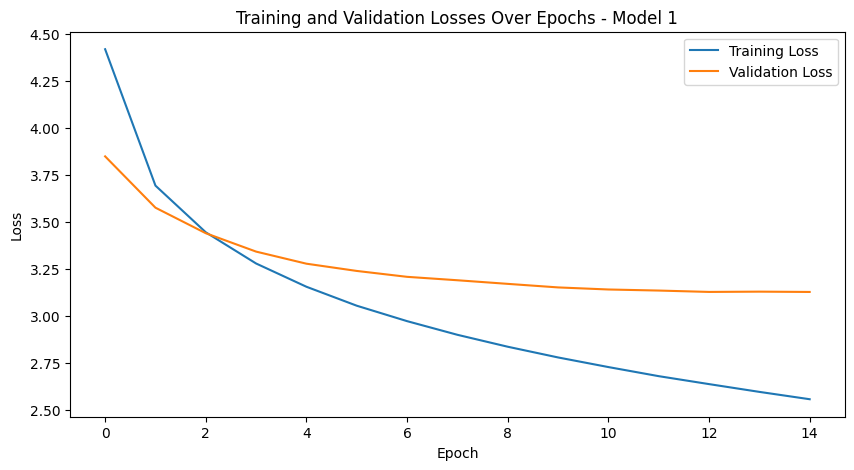

In [24]:
# Plotting Training vs Val
plt.figure(figsize=(10, 5))
plt.plot(train_losses_model1, label='Training Loss')
plt.plot(val_losses_model1, label='Validation Loss')
plt.title('Training and Validation Losses Over Epochs - Model 1')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [25]:
import os 
for f in os.listdir(MY_CHECKPTS):
    print(f)

model1_epoch1.pth
model1_epoch2.pth
model1_epoch3.pth
model1_epoch4.pth
model1_epoch5.pth
model1_epoch6.pth
model1_epoch7.pth
model1_epoch8.pth
model1_epoch9.pth
model1_epoch10.pth
model1_epoch11.pth
model1_epoch12.pth
model1_epoch13.pth
model1_epoch14.pth
model1_epoch15.pth


In [ ]:
# Epoch 13 had the best val loss, overfit is controlled
checkpoint = torch.load(MY_CHECKPTS / 'model1_epoch13.pth')
encoder_mobilenet.load_state_dict(checkpoint['encoder'])
decoder_gru.load_state_dict(checkpoint['decoder'])
print('Loaded checkpoint from epoch 13...')


Loaded checkpoint from epoch 13...


# Model 1 Bleu Score

In [27]:
def caption_generator_loader(encoder, decoder, loader, device, dataset, max_len = 30):
    encoder.eval()
    decoder.eval()

    # Reference
    all_refs = {}
    for img_id, tokens_list in captions_clean.items():
        fname = id_to_filename.get(img_id)
        if fname:
            all_refs[fname] = tokens_list

    generated_captions = []
    real_captions = []
    seen = set()

    with torch.no_grad():
        for batch_idx, (images, captions, lengths) in enumerate(tqdm(loader, desc='Generating captions')):
            images = images.to(device)
            features = encoder(images)

            for i in range(features.size(0)):
                # Getting filename
                sample_idx = batch_idx * loader.batch_size + i
                if sample_idx >= len(dataset.samples):
                    continue
                fname = dataset.samples[sample_idx][0].name

                # Skipping duplicates
                if fname in seen:
                    continue
                seen.add(fname)

                # Get all 5 references
                refs = all_refs.get(fname,[])
                if not refs:
                    continue

                #Generating caption
                feat = features[i].unsqueeze(0)
                pred_tokens = decoder.generate(feat, max_len=max_len)
                pred_words = [idx2word.get(t, '<UNK>') for t in pred_tokens]
                generated_captions.append(pred_words)
                real_captions.append(refs)

    return generated_captions, real_captions
                
            

         
def bleu_scores(generated_captions, real_captions):
    smoother = SmoothingFunction().method1

    bleu_1 = corpus_bleu(real_captions, generated_captions, weights=(1,0,0,0), smoothing_function=smoother)
    bleu_2 = corpus_bleu(real_captions, generated_captions, weights=(0.5, 0.5, 0, 0), smoothing_function=smoother)
    bleu_3= corpus_bleu(real_captions, generated_captions, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoother)
    bleu_4 = corpus_bleu(real_captions, generated_captions, weights=(0.25, 0.25,0.25,0.25), smoothing_function=smoother)
    return bleu_1, bleu_2, bleu_3, bleu_4



In [28]:
# Model 1 Evaluation
generated_captions, real_captions = caption_generator_loader(encoder_mobilenet, decoder_gru, test_loader, DEVICE, test_dataset)

bleu_1, bleu_2, bleu_3, bleu_4 = bleu_scores(generated_captions, real_captions)

print(f'BLEU-1: {bleu_1:.4f}')
print(f'BLEU-2: {bleu_2:.4f}')
print(f'BLEU-3: {bleu_3:.4f}')
print(f'BLEU-4: {bleu_4:.4f}')

Generating captions: 100%|██████████| 59/59 [05:24<00:00,  5.49s/it]


BLEU-1: 0.5612
BLEU-2: 0.4321
BLEU-3: 0.3480
BLEU-4: 0.2964


In [29]:
print(len(generated_captions))
print(len(real_captions))

774
774


In [30]:
def show_sample_captions(encoder, decoder, dataset, device, num_samples = 5):
    encoder.eval()
    decoder.eval()

    # References
    all_refs = {}
    for img_id, tokens_list in captions_clean.items():
        fname = id_to_filename.get(img_id)
        if fname:
            all_refs[fname] = tokens_list

    # Picking random samples:
    indices = random.sample(range(len(dataset.samples)), num_samples)

    fig, axes = plt.subplots(num_samples, 1, figsize=(12, num_samples * 4))

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            img_path, _ = dataset.samples[idx]
            fname = img_path.name

            # Loading and displying image
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img)
            ax.axis('off')

            # Generating Captions
            image_tensor = dataset.transform(img).unsqueeze(0).to(device)
            features = encoder(image_tensor)
            pred_tokens = decoder.generate(features)
            pred_words = [idx2word.get(t, '<UNK>') for t in pred_tokens if t not in [PAD_IDX, SOS_IDX, EOS_IDX]]
            generated = ' '.join(pred_words)

            # Getting real captions
            refs = all_refs.get(fname, [])
            refs_text = '\n'.join([' '.join(r) for r in refs[:5]]) # Showing all  refs

            ax.set_title(f'Generated:{generated}\n\nReference: {refs_text}', fontsize=10, loc='left', wrap=True)

    plt.tight_layout()
    plt.show()

### Model 1 — Visual inspection

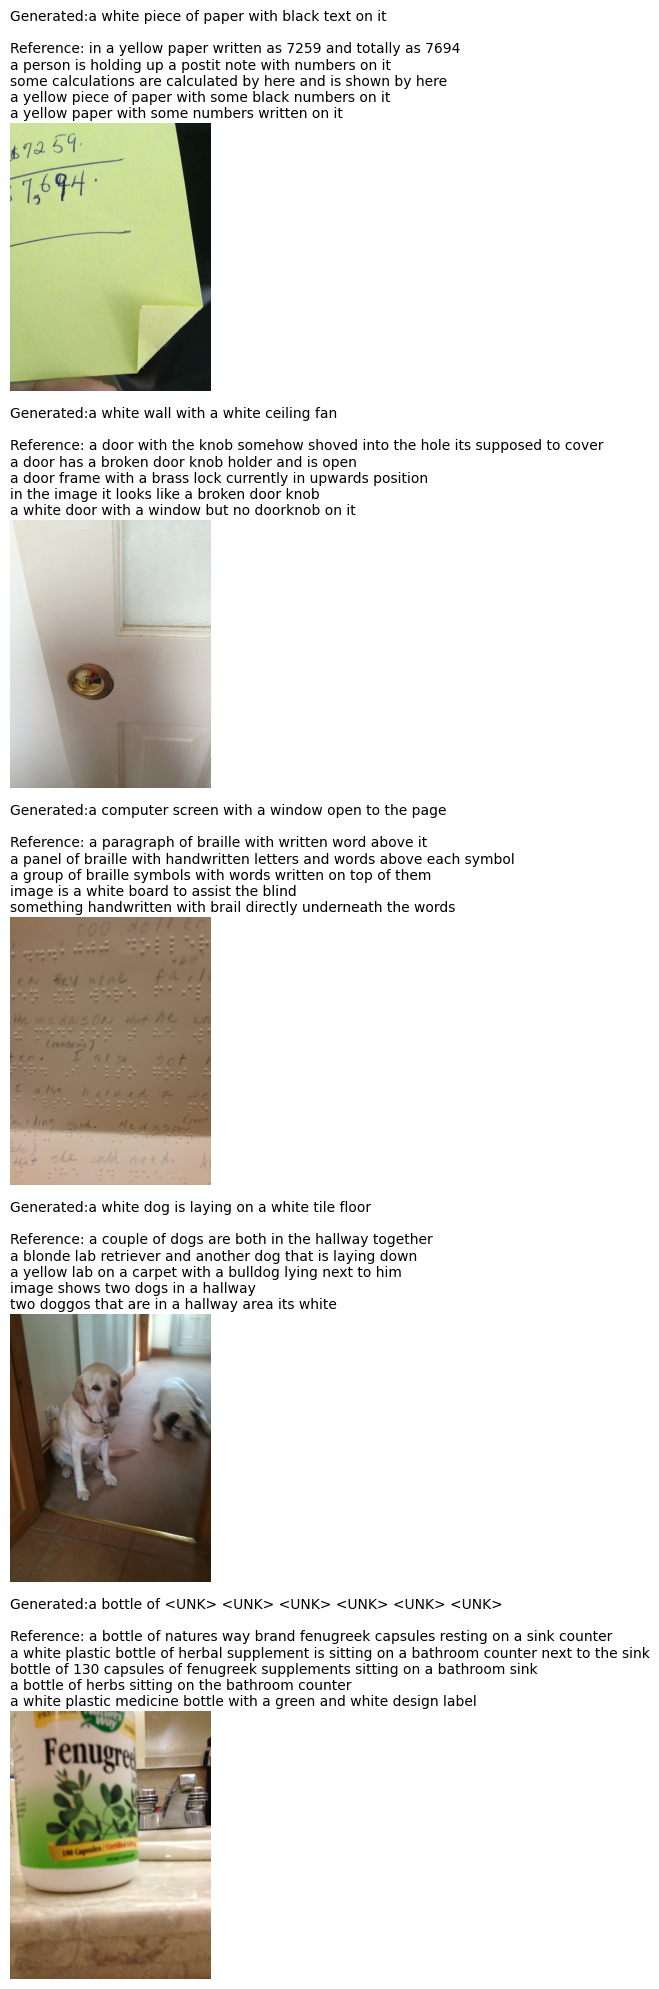

In [34]:
show_sample_captions(encoder_mobilenet, decoder_gru, test_dataset, DEVICE)

In [35]:
print(f'Unique images in test: {len(set(s[0].name for s in test_dataset.samples))}')
print(f'Total test samples: {len(test_dataset.samples)}')

Unique images in test: 774
Total test samples: 3751


In [36]:
print(f'Total test samples: {len(test_dataset.samples)}')
print(f'Total batches: {len(test_loader)}')
print(f'Last batch size: {3751 % 64}')

Total test samples: 3751
Total batches: 59
Last batch size: 39


---
# Group Discussion Summary

Two findings from the group discussion drove the Phase 3 decisions for all members: the absence of spatial attention was the primary structural limitation shared across all Phase 2 architectures, and encoder depth influenced performance in the cases where decoder pairing was held roughly constant. The group also agreed that rather than all implementing the same attention variant, each member would explore a different mechanism over their Phase 2 base architecture, allowing for a more meaningful comparison of attention types under controlled conditions. 


I  switched encoder from MobileNetV2 to GoogLeNet and added an attention mechanism to the decoder, directly addressing the two patterns identified in the group discussion: the sensitivity of MobileNetV3-Small to decoder pairing and the absence of spatial attention across all Phase 2 architectures.

---
# Model 2 — Phase 3 (Refined Architecture)



# Model 2 - GoogLeNet

For Model 2, I am using GoogLeNet + GRU + Bahdanau attention and the purpose of this architecture is to continue the genearation of caption for images by first extracting visual features from the image and then generating the sentence word by word, as we have seen in Model 1 when using MobileNet. GoogLeNet is a convolutional neural network (CNN) built around Inception blocks. It begins with a small set of convolutional and max pooling layers that extract basic features from the image. This initial block focuses on basic feature extraction, learning fundamental visual patterns like edges and textures, turning pixels into richer features maps. Its structure gets more complex by introducing Inception modules. Instead of using just one convolution path, it uses several paths in parallel inside the Inception block. As we can see, intead of using just one convolutional path, it uses parallel branches inside each Inception block, each looking ath the same input and getting different characteristics from it. There are different convolutions followed by max pooling, and they work in poarallel to find deeper patterns. 

In this model, I remove the final average pooling layer, the dropout layer and the classification layer and I do it because I do it, as we have seen in model 1, because I just want the feature extraction power from the model, not its classification. At the same time, I also want to keep the spatial visual information from the image intact. After removing  the final layers, GoogLeNet outputs a feature map with shape 1024 by 7 by 7 for each image. The 7x7 grid represents diferent spatial regions of the image, later each image represented by 49 visual regions and each region being represented by 1024 feature values. This is an import step since we are implementing Attention mechanism as attention needs multiple image regions to focus on. The encoder reshapes from (batch_size, 1024, 7,7) into (batch_size, 49, 1024). For every image in the batch, there are 49 region feature vectors. A linear layer is applied  and changes each region vector from 1024 dimension to 256 dimension, giving the final encoder output shape of (batch_size, 49, 256). 

The bahdanau attention mechanism is used to decide which of the 49 image regions is most relevant at each word generation step. The decoder hiddent state is the memory, representing what the GRU has generated or understood so far during the process. The attention mechanism combines both the image region features and the decoder hidden state into the same dimension, producing a score for each of the 49 regions. The scores are passed to tthe softmax function, which converts them into attention weights. A higher attention weight means that the model is focusing more on that image region. We calculates  the context vector by taking a weighted combinations of the 49 images region features, summaryzing the parts of the image that are most relevant for prediting the next word.


I also set up the GRU for the decoder. The decoder used the GRU to generate captions word by word. As we have seen in Model1, the decoder receives the real caption and it uses captions without the last token to learn to predict the next token at each time step. At each time step, the decoder takes the current word embedding (size 256), and the context vector (also  size 256) from the attention mechanism, and they are combined to an input of size 512 and then are passed into the GRU. As the pvector passes through the GRU, it updates its hidden state and productes and output vector , later converting the vector into scores for every word in the vocabulary. The word with the highest score is the predicted next word.

Therefore, the greatest strenght of this new model relies on the 49 spatial regions, allowing the decoder to focus on different regions whilhe generating different next words. WHen gemeration a work like "car", the model may focus on the region containing a vehicle. To our group understanding, this mechanisms allows the model to be more more flexible and to generalize better because it does not depend on a single global image representation, but it can dynamically select the most relevant visual information at each step of the caption generation while allowing different words in the caption to be supported by different areas of the image. 

# Model 2  Encoder, Attention, Decoder Structure:


1) Input Image (64, 3, 224, 224).
- There are 64 images in the batch, each image has 3 colour channels, and each image is resized to 224 x 224 pixels.



2) Encoder GoogLeNet
- GoogLeNet Backbone (64, 1024, 7,7) -> Permute + flatten (64, 49, 1024) -> FC Layer (64, 49, 256), 49 spatial regions.
- 49 spatial regions (64, 49, 256), one vector per region.

The image is passed through athe pretreined GoogLeNet backbone. The final average pooling, dropout and classificiation layers fc are removed because the model does not need class predictions but feature map understanding for attention.
The GoogLeNet backbone produces image features with shape (64, 1024, 7, 7), each image represented by 1024 features across 7x7 spatial grid. The feature map in permuted and reshaped. Since grid is 7x7, each image is represented as 49 spatial regions.
A fully connected layer then reduces each region from 1024 to 256 features.



3) Bahdanau Attention
- Encoder weight regions -> (64, 49, 512)
- Decoder wight hidden   -> (64, 1, 512)
- Tanh -> Scores -> softmax -> attention weights(64,49)
- context vector => weighted mix of the 49 regions -> (64,256). Focus on the most relevant region per word step.

At each word generation step Bahdanau attention calculates the 49 image regions that are the most important. Both Encoder and Decoder regions are combined and passed through tanh that gives a score for each of the 49 regions.
The scores as passed through softmax, which gives attention weights with shape (64,49). The attention wights show how much importance the model gives to each image region and these weights are used to create the context vector, the wighted misture of the 49 image regions.



4) Decoder - GRU
- Word embedding (64, 256) -> context vector (64,256)
- concat -> GRU input (64,512)
- GRU -> Hidden state memory (64, 512)
- FC -> word scores (64, 3965)
- argmax -> Predicts next word
At each step, the docoder receives word embeddings and the context vector. They are combined, passed to the GRU and updates the hidden state memory.
The GRU outputs is passed to a fully connected layer, which converts the memory into vocabulary scores.The model porduces a scroe for every word in the vocabulary. 
During training, these scores are compared with the real next word using cross-entropy loss  and during the caption generation, the model uses argmax to choose the word with the highest score as the predicted next word.

5) Generated caption
'a car is parked'  # example that I have been using.

The model process word by word until it predicts <EOS> token or reaches the maximum caption length of 30 that I chose.

Inspecting GoogleNet's structure. GoogleNet produces 1024 dimensional feature vector before the final classifier. Also, since I am using attention, I will not use avgpool because it collapses spatial information  and fc that is the classifier. For Bahdanau Attention, I need to keep the spatial features before pooling (batch_size x 1024 x 7 x 7) and reshape it to batch_size x 49 x 1024, where 49 becomes the image regions , allowing attention to chose which part of the image to focus when generating words.

Structure:
- Initial Feature Map: (batch_size, 1024, 7, 7)
- Reshape:             (batch_size, 49, 1024)
- Bahdanau Attention
- GRU decoder
- Caption Words

In [37]:
structure_model_2= googlenet(weights=GoogLeNet_Weights.DEFAULT)
print(structure_model_2)

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 120MB/s] 

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [38]:
structure_list_2 = list(structure_model_2.children())
for i, child in enumerate(structure_list_2):
    print(i, child.__class__.__name__)

0 BasicConv2d
1 MaxPool2d
2 BasicConv2d
3 BasicConv2d
4 MaxPool2d
5 Inception
6 Inception
7 MaxPool2d
8 Inception
9 Inception
10 Inception
11 Inception
12 Inception
13 MaxPool2d
14 Inception
15 Inception
16 AdaptiveAvgPool2d
17 Dropout
18 Linear


We will remove 3 layers, AdaptiveAvgPoll2d, Dropout, Linear. I will remove the last dropout to keep consistent what I a doing sicne I used dropout of 0.5 on the other class.
The spatial features should be (64, 1024, 7, 7).

# Model 2 Encoder:

In [39]:
# Model 2 architecture (GoogleNet + GRU + Bahdanau attention following what Amanda did on her model )
# Encoder -> GoogleNet  + Dropout + Bahdanau Attention
class EncoderCNN_GoogleNet_Attention(nn.Module): # Encoder to understand image patterns. Creating encoder class. It will inherit from nn.Module, pytorch base class for all neural networks.
    """Feature extractor using GoogleNet - Keeps 49 spatial regions for attention."""

    def __init__(self, embed_size): 
        super().__init__() 
        googlenet_model = googlenet(weights=GoogLeNet_Weights.DEFAULT) # I am removing 3 layers, AdaptiveAvgPoll2d, Dropout, Linear. I will remove the last dropout to keep consistent what I a doing sicne I used dropout of 0.5 on the other class.
        self.cnn = nn.Sequential(*list(googlenet_model.children())[:-3])
        self.dropout = nn.Dropout(0.5) # Keeping my own dropout to keep consistency.
        self.fc = nn.Linear(1024, embed_size) # Now this time it receives 1024 and converts to 256

    def forward(self, images): 
        features = self.cnn(images)                          # (64, 1024, 7,7) 1024 channels across a 7x7 grid
        features = features.permute(0, 2, 3, 1)              # (64, 7, 7, 1024) Rearranging the dimensions 
        features = features.reshape(features.size(0), -1, 1024) # (64, 49, 1024) Flatenning the 7x7 grid into 49 regions
        features = self.dropout(features) 
        features = self.fc(features)                         # (64, 49, 256) Compressing each region from 1024 to 256 features.
        return features

Verifying if encoder is working correctly. Expect: Input image batch shape (64, 3, 224, 224) and Encoder Outout shape (64, 49, 256)

In [40]:
test_encoder_google_attn = EncoderCNN_GoogleNet_Attention(EMBED_SIZE).to(DEVICE)
images, captions, lenghts = next(iter(train_loader))
images = images.to(DEVICE)

test_encoder_google_attn.eval()
with torch.no_grad():
    features = test_encoder_google_attn(images)
    print('Input image bartch shape:', images.shape)
    print('ENcoder output shape:', features.shape)

Input image bartch shape: torch.Size([64, 3, 224, 224])
ENcoder output shape: torch.Size([64, 49, 256])


# Model 2 Attention

In [41]:
# Setting up Bahdanau Attention
class BahdanauAttention(nn.Module): 
# Bahdanau Attention(nn.Module): Calculating which of the 49 image regions should be focused on at each word step.
    def __init__(self, hidden_size, embed_size):
        super().__init__()
        self.encoder_weight = nn.Linear(embed_size, hidden_size) # Transforming encoder features
        self.decoder_weight = nn.Linear(hidden_size, hidden_size) # Trasnforming decoder hidden state
        self.score_weight = nn.Linear(hidden_size, 1) # Converts everything to a single score per region  
    
    def forward(self, decoder_hidden, encoder_features): # decoder_hidden: (64,512) what the decoder learned so far. encoder_features: (64, 49, 256) the 49 image regions
        
        # 1. Transforming encoder features
        encoder_transformed = self.encoder_weight(encoder_features) # (64, 49, 512)
       
        # 2. Transforming decoder hidden state
        hidden_transformed = self.decoder_weight(decoder_hidden).unsqueeze(1) # (64, 1, 512)
       

        # 3. Adding encoder and decoder and applying tanh 
        combined_enco_deco = torch.tanh(encoder_transformed + hidden_transformed) # (64, 49, 512)

        # 4. Scores per region
        attention_scores = self.score_weight(combined_enco_deco).squeeze(2) # (64,49)

        # 5. Converting Scores to percentages
        attention_weights = torch.softmax(attention_scores, dim=1) # (64,49) 

        # 6. Weighted mix of the 49 regions
        attention_weights_expanded = attention_weights.unsqueeze(1)
        context_vector = torch.bmm(attention_weights_expanded, encoder_features).squeeze(1)

        return context_vector, attention_weights

In [42]:
# Testing class: Expecting Context Vector (64,256), Attention weights (64,49), Attention Weights sum (1)
t_attention = BahdanauAttention(HIDDEN_SIZE, EMBED_SIZE).to(DEVICE)
t_attention.eval()

t_encoder_features = torch.randn(64, 49, EMBED_SIZE).to(DEVICE)
t_decoder_hidden = torch.randn(64, HIDDEN_SIZE).to(DEVICE)

with torch.no_grad():
    t_context_vector, t_attention_weights = t_attention(t_decoder_hidden, t_encoder_features)

print('Context vector shape:', t_context_vector.shape)
print('Attention weights shape:', t_attention_weights.shape)
print('Attention weights sums:', t_attention_weights[0].sum())

Context vector shape: torch.Size([64, 256])
Attention weights shape: torch.Size([64, 49])
Attention weights sums: tensor(1., device='cuda:0')


# Implemente GRU Decoder and Using Bahdanau Attention

In [43]:
class DecoderRNN_Bahdanau(nn.Module): # Generates captions word by word using attention to focus on different image regions.
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.dropout = nn.Dropout(0.5)
        self.attention = BahdanauAttention(hidden_size, embed_size)
        self.gru = nn.GRU(embed_size + embed_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size) # converts hidden state to word scores

    def forward(self, encoder_features, captions):
        embeddings = self.embed(captions[:, :-1]) # Removing <EOS>, (64, seq_len,256)
        embeddings = self.dropout(embeddings)

        hidden = None # starting with no memory
        outputs = [] # Collecting word scores
        
        for t in range(embeddings.size(1)): #Loop each word
            word_embed = embeddings[:, t, :] # current word, (64, 256)

            if hidden is None:
                decoder_hidden = torch.zeros(1, encoder_features.size(0), self.hidden_size).to(encoder_features.device)
            else:
                decoder_hidden = hidden
            
            # Attention called before GRU
            context_vector, _ = self.attention(decoder_hidden.squeeze(0), encoder_features)
            
            # Combining word embedding + context vector
            gru_input = torch.cat([word_embed, context_vector], dim=1).unsqueeze(1)
            gru_output, hidden = self.gru(gru_input, hidden)
            word_scores = self.fc(gru_output.squeeze(1)) # (64, vocab_size)
            outputs.append(word_scores)
        
        return torch.stack(outputs, dim=1) # (64, seq_len, vocab_size)
    
    def generate(self, encoder_features, max_len = 30):
        result = []
        hidden = None
        word_idx = torch.tensor([[SOS_IDX]]).to(encoder_features.device)

        for _ in range(max_len):
            word_embed = self.embed(word_idx).squeeze(1)  #(1,256)

            if hidden is None:
                decoder_hidden = torch.zeros(1, 1, self.hidden_size).to(encoder_features.device)
            else:
                decoder_hidden = hidden

            context_vector, _ = self.attention(decoder_hidden.squeeze(0), encoder_features)
            gru_input = torch.cat([word_embed, context_vector], dim=1).unsqueeze(1)
            gru_output, hidden = self.gru(gru_input, hidden)
            predicted = self.fc(gru_output.squeeze(1)).argmax(dim=1)
            word_idx_val = predicted.item()

            if word_idx_val == EOS_IDX:
                break
            result.append(word_idx_val)
            word_idx = predicted.unsqueeze(0)

        return result



In [44]:
EMBED_SIZE  = 256
HIDDEN_SIZE = 512
NUM_LAYERS  = 1
EPOCHS      = 15
LR          = 3e-4

# Creating encoder and decoder
encoder_googlenet = EncoderCNN_GoogleNet_Attention(EMBED_SIZE).to(DEVICE)
decoder_bahdanau = DecoderRNN_Bahdanau(EMBED_SIZE, HIDDEN_SIZE, VOCAB_SIZE, NUM_LAYERS).to(DEVICE)

# Freezing weights
for param in encoder_googlenet.cnn.parameters():
    param.requires_grad = False

# Creating optimizer afetr freezing
optimizer2 = optim.Adam(list(encoder_googlenet.parameters()) + list(decoder_bahdanau.parameters()), lr=LR)

# Shapes
images, captions, lengths = next(iter(train_loader))
images = images.to(DEVICE)
captions = captions.to(DEVICE)



features = encoder_googlenet(images)
print(f'Encoder output shape: {features.shape}') # Expects (64,49,256), GoogleNet keeps 49 spatial regions
outputs = decoder_bahdanau(features, captions)
print(f'Decoder output shape: {outputs.shape}') # Expects (64, seq_len, vocab_size)

Encoder output shape: torch.Size([64, 49, 256])
Decoder output shape: torch.Size([64, 21, 3965])


In [45]:
# Testing Decoder - Expecting (5, 14, VOCAB_SIZE = 3965)
t_deco = DecoderRNN_Bahdanau(EMBED_SIZE,HIDDEN_SIZE,VOCAB_SIZE,NUM_LAYERS).to(DEVICE)
t_deco.eval()

t_feat = torch.randn(5,49, EMBED_SIZE).to(DEVICE)
t_capt = torch.randint(0, VOCAB_SIZE, (5,15)).to(DEVICE)

with torch.no_grad():
    t_outp = t_deco(t_feat, t_capt)

print(f'Decoder output: {t_outp.shape}')

Decoder output: torch.Size([5, 14, 3965])


In [46]:
# Final Test Encoder
test_img = torch.randn(2,3,224,224).to(DEVICE)
test_encoder = EncoderCNN_GoogleNet_Attention(EMBED_SIZE).to(DEVICE)
test_features = test_encoder(test_img)
print(f'Encoder output:{test_features.shape}') # Should be (2,49,256) 2 batch size, 49 (7x7 spatial regions(the key difference from Model 1))

Encoder output:torch.Size([2, 49, 256])


In [47]:
# Final Test Decoder 
test_decoder = DecoderRNN_Bahdanau(EMBED_SIZE, HIDDEN_SIZE, VOCAB_SIZE, NUM_LAYERS).to(DEVICE)
test_captions = torch.randint(0, VOCAB_SIZE, (2, 15)).to(DEVICE)
test_outputs = test_decoder(test_features, test_captions)
print(f'Decoder output: {test_outputs.shape}') # Should be (2, 14, 3965) 2 batch size, 14(seq_len -1 -> 15-1  removed EOS!, 3965 vocab size)

Decoder output: torch.Size([2, 14, 3965])


### Model 2 — Training

In [48]:
# Training loop for GoogleNet (GoogleNet + GRU + Bahdanau Attention)
train_losses_model2 = []
val_losses_model2 = []
criterion2 = nn.CrossEntropyLoss(ignore_index=PAD_IDX)



for epoch in range(EPOCHS):
    #Training Loop
    encoder_googlenet.train() # Setting up training mode for both encoder and decoder
    encoder_googlenet.cnn.eval()
    decoder_bahdanau.train()
    total_loss = 0

    for images, captions, lengths in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}'):
        images = images.to(DEVICE)
        captions = captions.to(DEVICE)

        # Forward pass
        optimizer2.zero_grad() # Clear old gradients
        features = encoder_googlenet(images) # pass images through encoder, getting (64,49,256)
        outputs = decoder_bahdanau(features, captions) # pass features and captions on decoder, getting word scores

        # Loss Calculation
        targets = captions[:, 1:] # remove <SOS>
        loss = criterion2(torch.flatten(outputs, 0, 1), torch.flatten(targets, 0, 1)) # flatten prediction and target, from dimension 0 to dimension 1.

        # Backpropagation. Calculate mistake to figure out what variable is responsable and fix it.
        loss.backward() # Calculates how much each weight contributed to the error
        optimizer2.step() # Updates all weights, trying to reduce the error
        total_loss += loss.item() # add the current batch loss to the total.

    avg_train_loss = total_loss / len(train_loader)
    train_losses_model2.append(avg_train_loss)
    print(f'Epoch [{epoch+1}/{EPOCHS}] Train Loss: {avg_train_loss:.4f}')

    # Validation
    encoder_googlenet.eval()
    decoder_bahdanau.eval()
    val_loss = 0

    with torch.no_grad():
        for images, captions, lengths in tqdm(val_loader, desc='Validating'):
            images = images.to(DEVICE)
            captions = captions.to(DEVICE)

            features = encoder_googlenet(images)
            outputs = decoder_bahdanau(features, captions)

            targets = captions[: , 1:]
            loss = criterion2(torch.flatten(outputs, 0, 1), torch.flatten(targets, 0, 1))

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses_model2.append(avg_val_loss)
    print(f'Epoch [{epoch+1}/{EPOCHS}] Val Loss: {avg_val_loss:.4f}')



    # Save checkpoints

    torch.save({
        'encoder': encoder_googlenet.state_dict(),
        'decoder': decoder_bahdanau.state_dict(),
        'optimizer': optimizer2.state_dict(),
        'epoch':epoch,
        'train_losses': train_losses_model2,
        'val_losses': val_losses_model2}, MY_CHECKPTS / f'model2_epoch{epoch+1}.pth')

print("Model 2 Training Completed...")

Epoch 1/15: 100%|██████████| 469/469 [11:19<00:00,  1.45s/it]


Epoch [1/15] Train Loss: 4.4055


Validating: 100%|██████████| 59/59 [01:18<00:00,  1.33s/it]


Epoch [1/15] Val Loss: 3.8145


Epoch 2/15: 100%|██████████| 469/469 [11:15<00:00,  1.44s/it]


...

Epoch [14/15] Val Loss: 3.1850


Epoch 15/15: 100%|██████████| 469/469 [11:08<00:00,  1.43s/it]


Epoch [15/15] Train Loss: 2.3669


Validating: 100%|██████████| 59/59 [01:17<00:00,  1.31s/it]


Epoch [15/15] Val Loss: 3.1962
Model 2 Training Completed...


### Model 2 — Evaluation (BLEU-1 to BLEU-4)

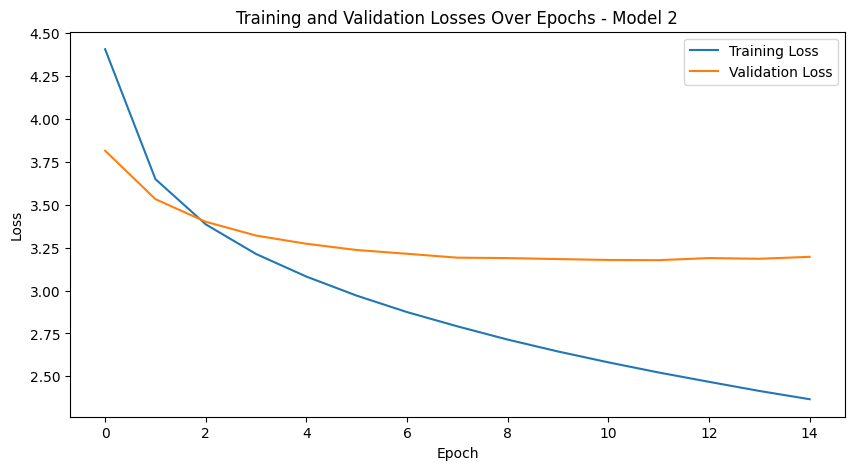

In [49]:
# Plotting Training vs Val
plt.figure(figsize=(10, 5))
plt.plot(train_losses_model2, label='Training Loss')
plt.plot(val_losses_model2, label='Validation Loss')
plt.title('Training and Validation Losses Over Epochs - Model 2')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [50]:
for f in os.listdir(MY_CHECKPTS):
   print(f)

model1_epoch1.pth
model1_epoch2.pth
model1_epoch3.pth
model1_epoch4.pth
model1_epoch5.pth
model1_epoch6.pth
model1_epoch7.pth
model1_epoch8.pth
model1_epoch9.pth
model1_epoch10.pth
model1_epoch11.pth
model1_epoch12.pth
model1_epoch13.pth
model1_epoch14.pth
model1_epoch15.pth
model2_epoch1.pth
model2_epoch2.pth
model2_epoch3.pth
model2_epoch4.pth
model2_epoch5.pth
model2_epoch6.pth
model2_epoch7.pth
model2_epoch8.pth
model2_epoch9.pth
model2_epoch10.pth
model2_epoch11.pth
model2_epoch12.pth
model2_epoch13.pth
model2_epoch14.pth
model2_epoch15.pth


In [51]:
# Best epoch is epoch 12
checkpoint2 = torch.load(MY_CHECKPTS / 'model2_epoch12.pth')
encoder_googlenet.load_state_dict(checkpoint2['encoder'])
decoder_bahdanau.load_state_dict(checkpoint2['decoder'])
print('Loaded checkpoint from epoch 12...')

Loaded checkpoint from epoch 12...


Update BLEU below

In [52]:
# Model 2 Evaluation
generated_captions, real_captions = caption_generator_loader(encoder_googlenet, decoder_bahdanau, test_loader, DEVICE, test_dataset)

bleu_1, bleu_2, bleu_3, bleu_4 = bleu_scores(generated_captions, real_captions)

print(f'BLEU-1: {bleu_1:.4f}')
print(f'BLEU-2: {bleu_2:.4f}')
print(f'BLEU-3: {bleu_3:.4f}')
print(f'BLEU-4: {bleu_4:.4f}')

Generating captions: 100%|██████████| 59/59 [01:22<00:00,  1.40s/it]


BLEU-1: 0.5757
BLEU-2: 0.4126
BLEU-3: 0.3029
BLEU-4: 0.2369


images

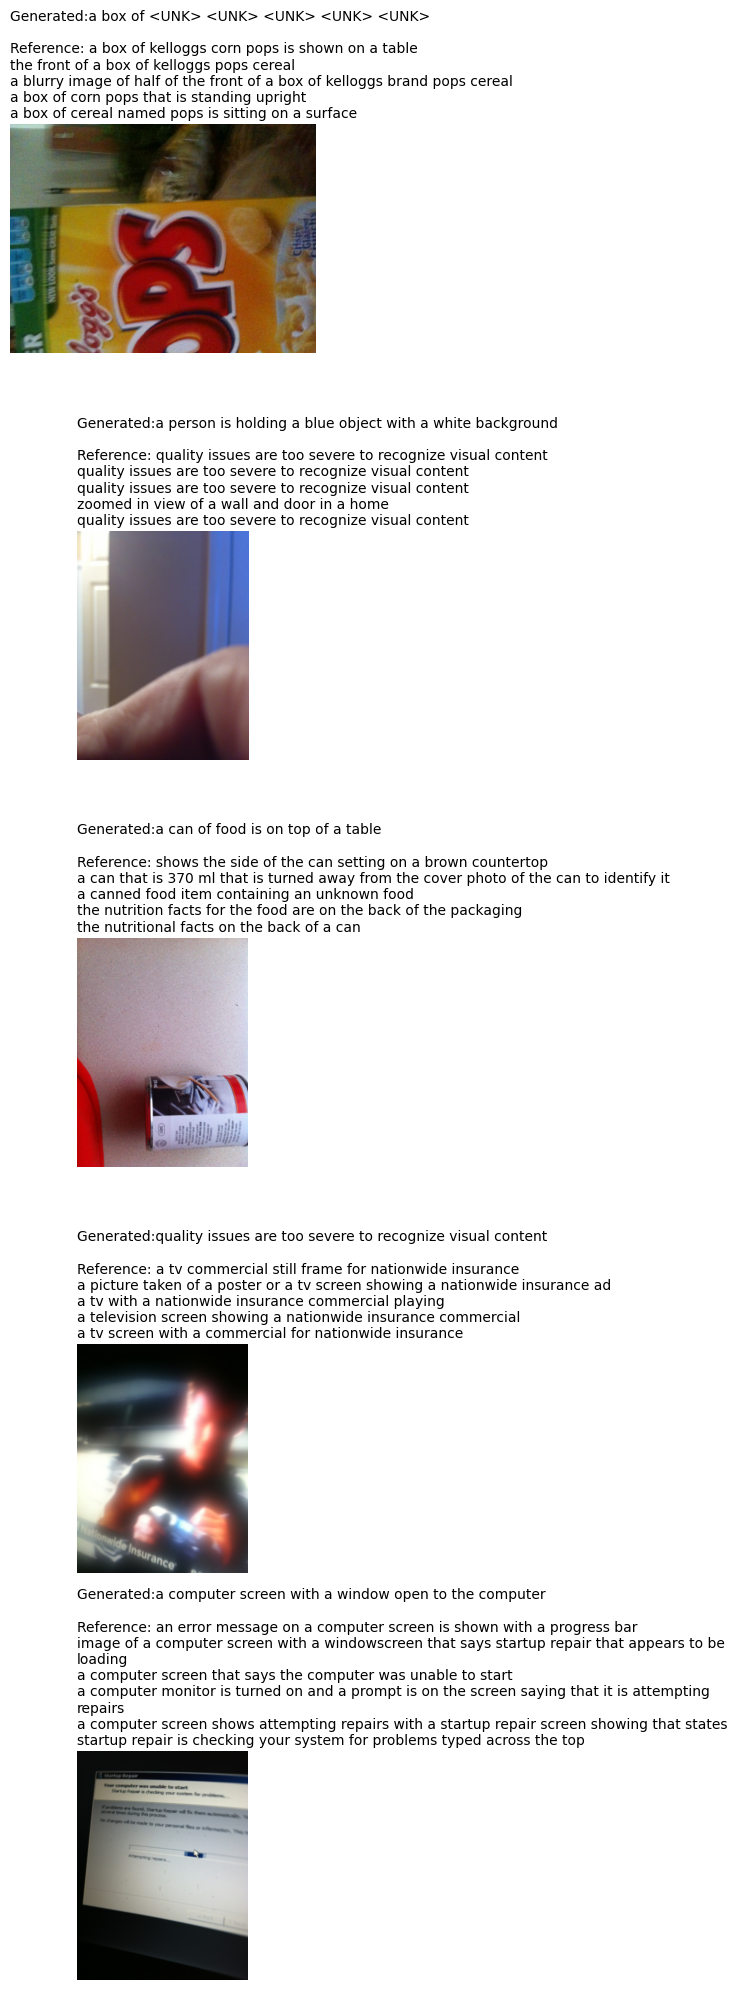

In [54]:
show_sample_captions(encoder_googlenet, decoder_bahdanau, test_dataset, DEVICE)